In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
import scanpy as sc
from codes.config import LSDConfig
from codes.lsd_train import LSD

import pyro
import torch
import pandas as pd
from pathlib import Path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


=== Training with clusters removed: DCs ===
[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 200/200 [44:08<00:00, 13.24s/it, -ELBO=0.6049, Potential Metric=0.1756, Entropy Metric=0.0451]


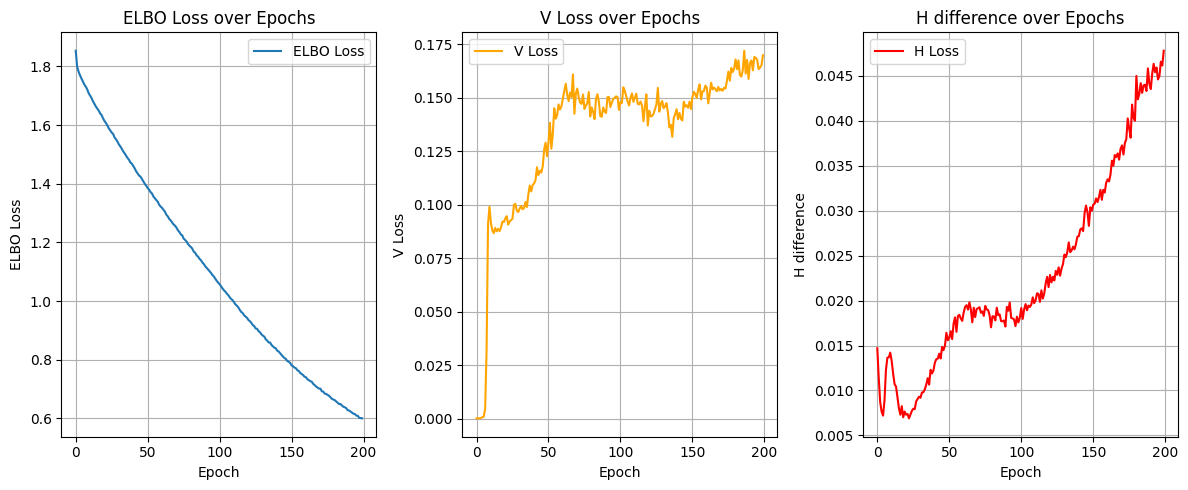


=== Training with clusters removed: Ery_1 ===
[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 200/200 [42:38<00:00, 12.79s/it, -ELBO=0.6207, Potential Metric=0.1030, Entropy Metric=0.0649]


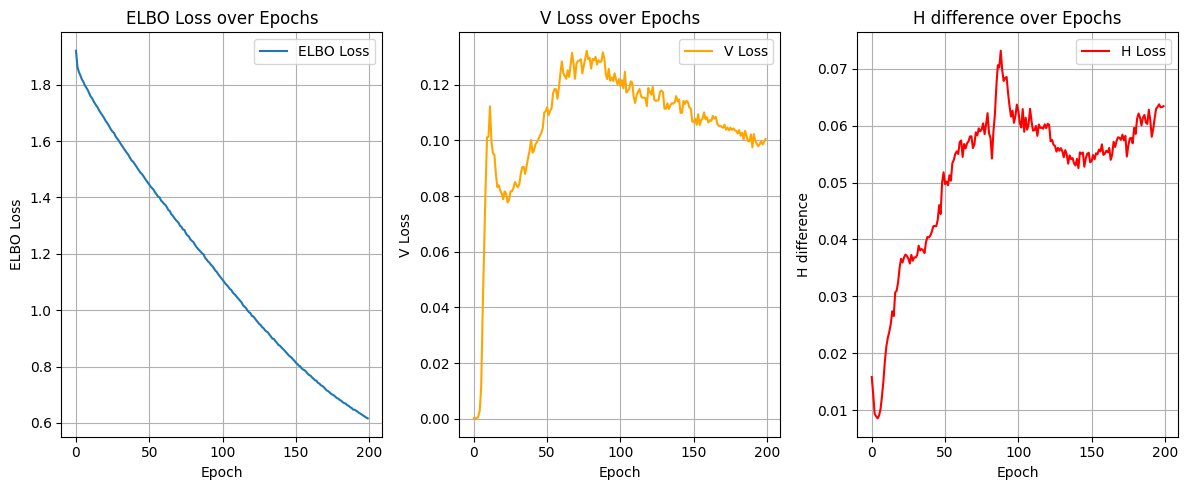


=== Training with clusters removed: HSC_1 ===
[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 200/200 [48:27<00:00, 14.54s/it, -ELBO=0.5924, Potential Metric=0.1139, Entropy Metric=0.0287]


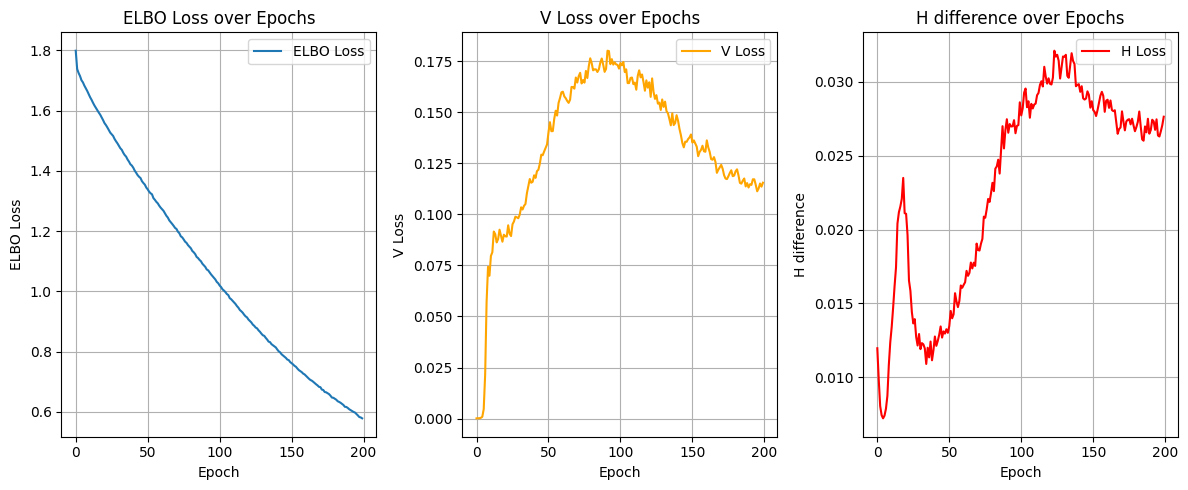


=== Training with clusters removed: Mono_1 ===
[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 200/200 [42:35<00:00, 12.78s/it, -ELBO=0.6692, Potential Metric=0.0886, Entropy Metric=0.0530]


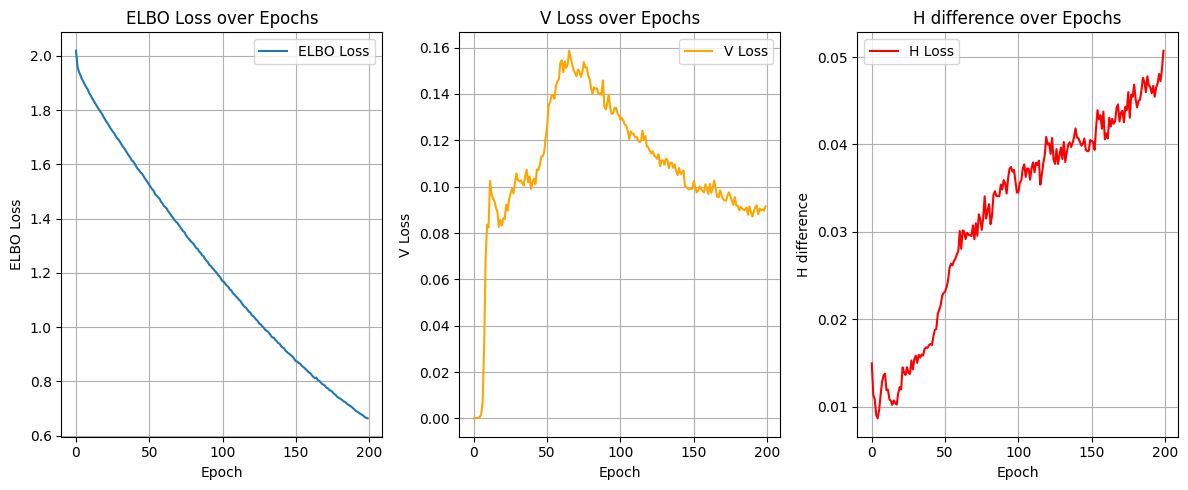


=== Training with clusters removed: Precursors ===
[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 200/200 [59:04<00:00, 17.72s/it, -ELBO=0.5825, Potential Metric=0.1444, Entropy Metric=0.0375]


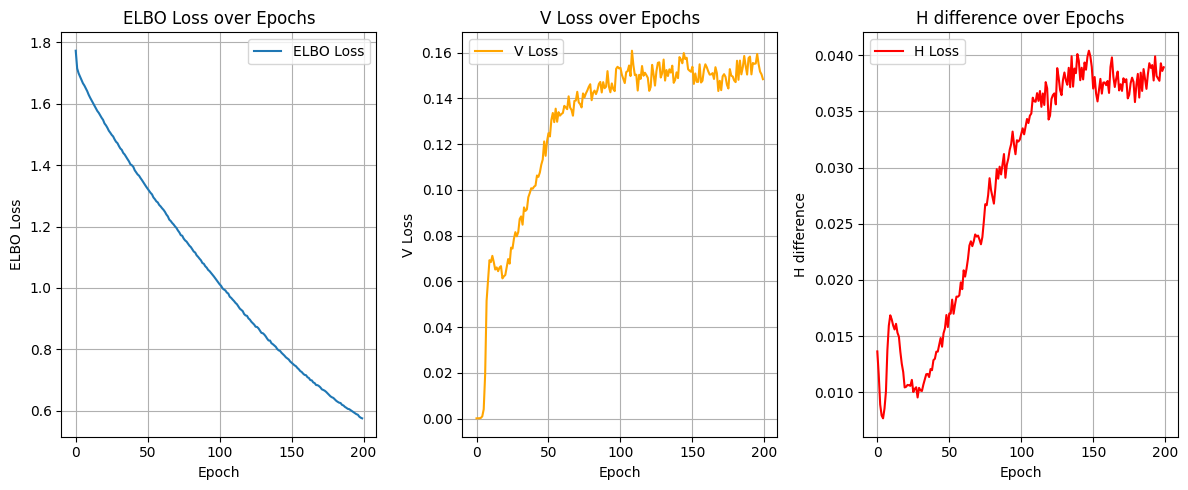


=== Training with clusters removed: HSC_2 ===
[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 200/200 [50:45<00:00, 15.23s/it, -ELBO=0.5738, Potential Metric=0.1112, Entropy Metric=0.0317]


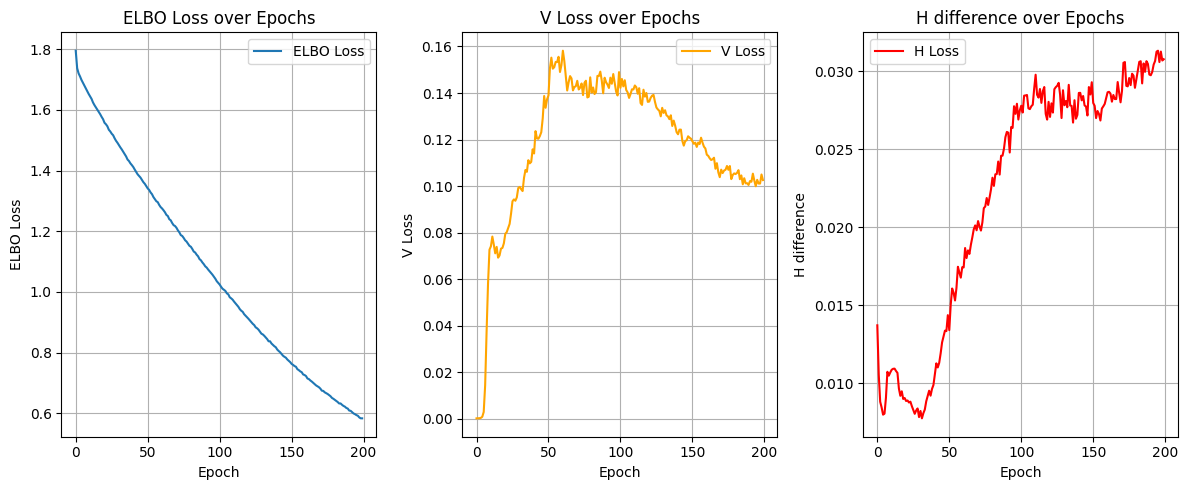


=== Training with clusters removed: Mono_2 ===
[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 200/200 [1:06:31<00:00, 19.96s/it, -ELBO=0.5965, Potential Metric=0.0891, Entropy Metric=0.0241]


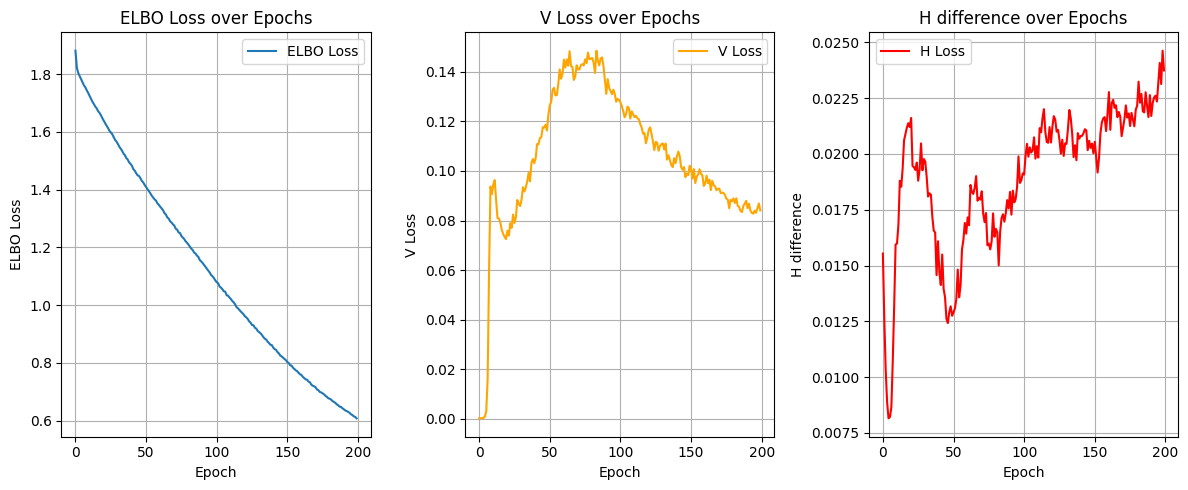


=== Training with clusters removed: Ery_2 ===
[LSD] Prior transition matrix set from pseudotime and connectivities.


Training Epochs: 100%|██████████| 200/200 [1:37:09<00:00, 29.15s/it, -ELBO=0.6124, Potential Metric=0.1347, Entropy Metric=0.0444]


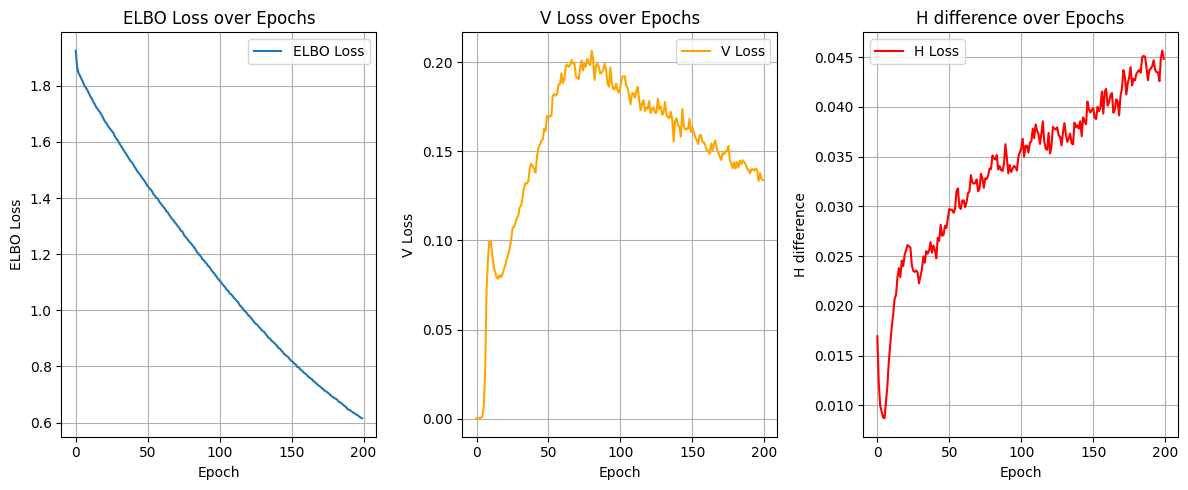

In [2]:
# -----------------------------------------------------------------------------
# 1. Load main dataset
# -----------------------------------------------------------------------------
main_adata = sc.read_h5ad("../../data/BoneMarrow/normalized_before_low.h5ad")

# -----------------------------------------------------------------------------
# 3. Experimental parameters
# -----------------------------------------------------------------------------
CLUSTERS_TO_LEAVE_OUT = [
    'DCs', 'Ery_1', 'HSC_1', 'Mono_1', 
    'Precursors', 'HSC_2', 'Mono_2', 'Ery_2'
]
EMBEDDING_KEY = "X_tsne"
PRIOR_TIME_KEY = "palantir_pseudotime"

# -----------------------------------------------------------------------------
# 4. Leave-one-out training loop
# ----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# 4. Leave-one-out (and combos) training loop
# -----------------------------------------------------------------------------
out_path = Path("loo_cell_fates.csv")
df = pd.DataFrame(index=main_adata.obs_names)  # fixed index = all cell IDs
for excluded in CLUSTERS_TO_LEAVE_OUT:

    print(f"\n=== Training with clusters removed: {excluded} ===")

    # 4.1 Remove the specified cluster(s) from training data
    train_mask = ~(main_adata.obs['clusters'] == excluded)
    train_adata = main_adata[train_mask].copy()

    # recompute KNN graph
    sc.pp.pca(train_adata)
    sc.pp.neighbors(train_adata)

    cfg = LSDConfig()
    cfg.optimizer.kl_schedule.af = 2
    cfg.walks.batch_size = 256
    cfg.walks.path_len = 10
    cfg.walks.num_walks = 4096
    # 4.2 Initialize LSD model
    pyro.set_rng_seed(42)
    lsd_model = LSD(
        adata=train_adata,
        config = cfg,
        device=device,                 # as in your original script
        lib_size_key="librarysize",
        raw_count_key="raw",
    )

    # 4.3 Configure prior and random walks
    lsd_model.set_prior_transition(prior_time_key=PRIOR_TIME_KEY)
    lsd_model.prepare_walks()



    # 4.4 Clear previous parameters and train
    pyro.clear_param_store()
    save_dir = f"../../Models/{excluded}_bonemarrow"
    lsd_model.train(
        num_epochs=200,
        save_dir=save_dir,
        save_interval=50
    )

    # -------------------------------------------------------------------------
    # 4.6 Test on full dataset (all clusters)
    # -------------------------------------------------------------------------
    test_adata = main_adata[:, train_adata.var_names].copy()  # restrict to training genes
    lsd_model.set_adata(test_adata)
    final_adata = lsd_model.get_adata()
    dyn_adata = lsd_model.get_cell_fates(final_adata, time_range = 10, batch_size= 2700, cluster_key= "clusters")
    fate_col = f"fate_excluding_{excluded}"
    s = pd.Series(dyn_adata.obs["fate"].astype(str).values, index=dyn_adata.obs_names, name=fate_col)
    df[fate_col] = s.reindex(df.index)  # align to main_adata.obs_names

    df.to_csv(out_path)

